In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import tf_keras
import os
import re
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import yake
from rake_nltk import Rake
from sklearn.feature_extraction.text import TfidfVectorizer
from keybert import KeyBERT
from wordcloud import WordCloud

> # 1. Load dataset

In [16]:
Data = pd.read_csv("ai_ml_jobs_linkedin.csv")
Data.head(3)

,title,location,publishedAt,companyName,description,applicationsCount,contractType,experienceLevel,workType,sector
0,AI/ML Engineer,"New York, NY",2024-05-29,Wesper,THE OPPORTUNITY\n\nWesper is looking for a sma...,Over 200 applicants,Full-time,Mid-Senior level,Engineering and Information Technology,Internet Publishing
1,Software Engineer - AI/ML Systems,"Redwood City, CA",NaN,Snorkel AI,We're on a mission to democratize AI by buildi...,51 applicants,Full-time,Entry level,Engineering and Information Technology,Software Development
2,ML Engineer at 100% Remote,"San Jose, CA",2024-06-01,ELITE MENTE LLC,"Hello ,\n\nHope you are doing well!\n\nPlease ...",Be among the first 25 applicants,Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting


> # 2. Dataset information

In [17]:
print(f"The shape of Dataframe is : {Data.shape}")

The shape of Dataframe is : (862, 10)


In [18]:
print(f"\nThe information of Dataframe is : {Data.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              862 non-null    object
 1   location           862 non-null    object
 2   publishedAt        850 non-null    object
 3   companyName        861 non-null    object
 4   description        862 non-null    object
 5   applicationsCount  862 non-null    object
 6   contractType       862 non-null    object
 7   experienceLevel    862 non-null    object
 8   workType           862 non-null    object
 9   sector             859 non-null    object
dtypes: object(10)
memory usage: 67.5+ KB

The information of Dataframe is : None


In [19]:
Data.describe().T

,count,unique,top,freq
title,862,450,Machine Learning Engineer,146
location,862,164,United States,140
publishedAt,850,142,2024-05-22,136
companyName,861,519,"Unreal Staffing, Inc",45
description,862,748,Grammarly is excited to offer a remote-first h...,17
applicationsCount,862,145,Over 200 applicants,371
contractType,862,5,Full-time,744
experienceLevel,862,7,Mid-Senior level,403
workType,862,55,Engineering and Information Technology,557
sector,859,156,Software Development,197


In [20]:
print(f"The Duplicates are : {Data.duplicated().sum()}")
Data.drop_duplicates(inplace=True)
print(f"\nThe Duplicates are : {Data.duplicated().sum()}")
print(f"\nThe shape of Dataframe is : {Data.shape}")


The Duplicates are : 3

The Duplicates are : 0

The shape of Dataframe is : (859, 10)



The null values are : 
title                 0
location              0
publishedAt          12
companyName           1
description           0
applicationsCount     0
contractType          0
experienceLevel       0
workType              0
sector                3
dtype: int64


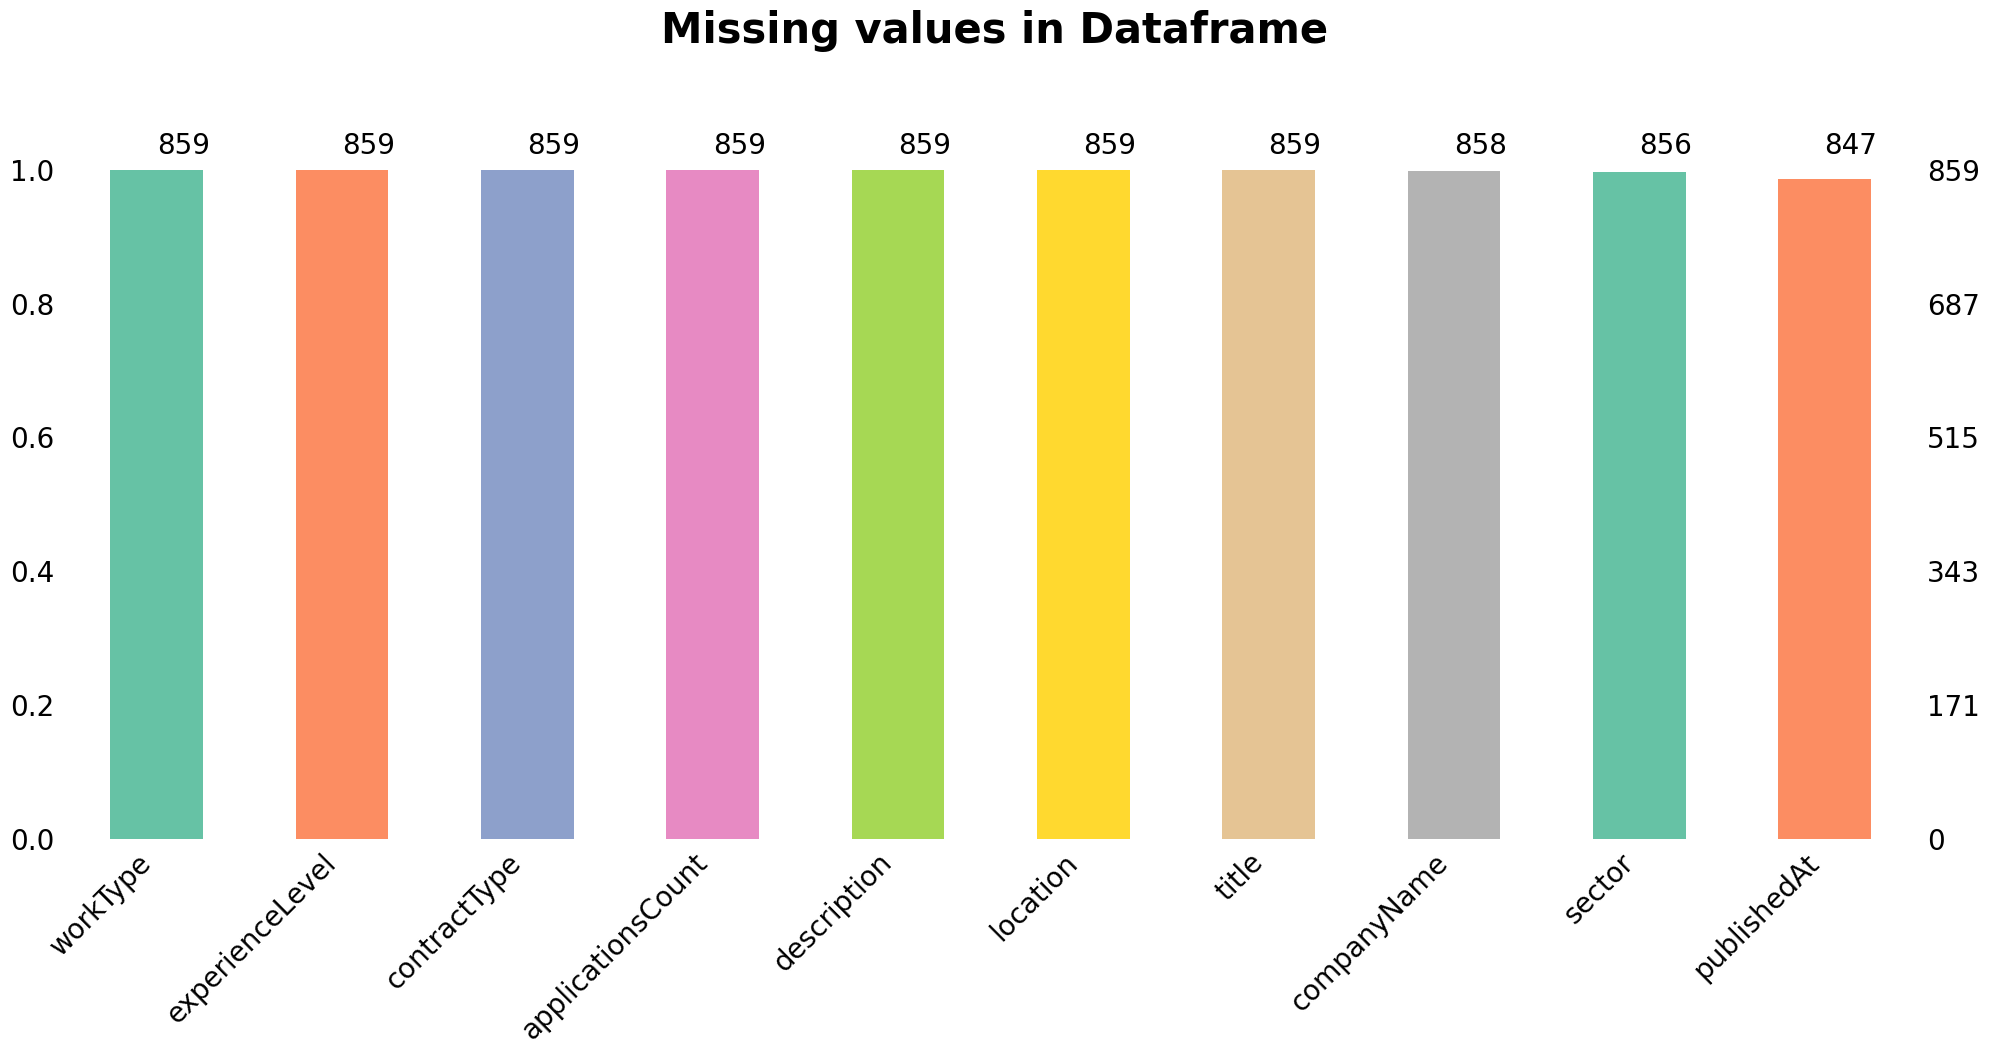

In [ ]:
print(f"\nThe null values are : \n{Data.isnull().sum()}")

MyColors = sns.color_palette("Set2")

msno.bar(Data, color = MyColors, figsize = (20, 10), fontsize = 20, sort = "descending", label_rotation = 45, )
plt.suptitle("Missing values in Dataframe", fontsize = 30, fontweight = "bold", y = 1.05)
plt.xticks(rotation = 0, fontsize = 20)
plt.tight_layout()
plt.show()

> # 3. Preparation

> ## 3.1. Fill Nulls
> ### Given that the data is not sensitive, we fill the null values randomly from within their respective columns

In [22]:
def fill_NaN_randomly(column):
    NaN_value = column.dropna().values

    for i in range(len(column)):
        if pd.isna(column.iloc[i]):
            column.iloc[i] = np.random.choice(NaN_value)
    return column

Data["publishedAt"] = fill_NaN_randomly(Data["publishedAt"])
Data["companyName"] = fill_NaN_randomly(Data["companyName"])
Data["sector"] = fill_NaN_randomly(Data["sector"])

Data.isnull().sum()

title                0
location             0
publishedAt          0
companyName          0
description          0
applicationsCount    0
contractType         0
experienceLevel      0
workType             0
sector               0
dtype: int64

> ## 3.2. Splitting the published date into year, month, and day

In [23]:
Data["publishedAt"] = pd.to_datetime(Data["publishedAt"])

Data["publishedYear"] = Data["publishedAt"].dt.year
Data["publishedMonth"] = Data["publishedAt"].dt.month
Data["publishedDay"] = Data["publishedAt"].dt.day

Data.head(3)


,title,location,publishedAt,companyName,description,applicationsCount,contractType,experienceLevel,workType,sector,publishedYear,publishedMonth,publishedDay
0,AI/ML Engineer,"New York, NY",2024-05-29,Wesper,THE OPPORTUNITY\n\nWesper is looking for a sma...,Over 200 applicants,Full-time,Mid-Senior level,Engineering and Information Technology,Internet Publishing,2024,5,29
1,Software Engineer - AI/ML Systems,"Redwood City, CA",2024-03-03,Snorkel AI,We're on a mission to democratize AI by buildi...,51 applicants,Full-time,Entry level,Engineering and Information Technology,Software Development,2024,3,3
2,ML Engineer at 100% Remote,"San Jose, CA",2024-06-01,ELITE MENTE LLC,"Hello ,\n\nHope you are doing well!\n\nPlease ...",Be among the first 25 applicants,Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,2024,6,1


> ## 3.3. Extracting only the count of applications used

In [24]:
Data["appCount"] = Data["applicationsCount"].str.extract(r"(\d+)")
Data.head(3)

,title,location,publishedAt,companyName,description,applicationsCount,contractType,experienceLevel,workType,sector,publishedYear,publishedMonth,publishedDay,appCount
0,AI/ML Engineer,"New York, NY",2024-05-29,Wesper,THE OPPORTUNITY\n\nWesper is looking for a sma...,Over 200 applicants,Full-time,Mid-Senior level,Engineering and Information Technology,Internet Publishing,2024,5,29,200
1,Software Engineer - AI/ML Systems,"Redwood City, CA",2024-03-03,Snorkel AI,We're on a mission to democratize AI by buildi...,51 applicants,Full-time,Entry level,Engineering and Information Technology,Software Development,2024,3,3,51
2,ML Engineer at 100% Remote,"San Jose, CA",2024-06-01,ELITE MENTE LLC,"Hello ,\n\nHope you are doing well!\n\nPlease ...",Be among the first 25 applicants,Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,2024,6,1,25


> ## 3.4. ِDiscription Optimizing
> ### The description column contains complete information about the job posting. However, much of this information is neither practical nor useful. To extract meaningful and relevant keywords, natural language processing (NLP) techniques can be applied. However, as a first step, the text should be optimized and cleaned using the following methods:
> ### Lowercasing the text
> ### Removing punctuation
> ### Tokenization
> ### Removing stop words
> ### In the next step, we need to apply natural language processing techniques to the cleaned text to evaluate and identify the most effective technique for our needs.

In [25]:
CopyData = Data.copy()

In [ ]:
nltk.download("punkt")
nltk.download("stopwords")

# Lowercasing and removing punctuation
def clean_text(text): 
    text = text.lower()  # Convert to lowercase
    text = text.translate(str.maketrans("", "", string.punctuation))  # Remove punctuation
    return text

CopyData["Clean_description"] = CopyData["description"].apply(clean_text)


# Tokenization
def tokenize_text(text):
    return word_tokenize(text)

CopyData["Tokens"] = CopyData["Clean_description"].apply(tokenize_text)


# Remove stop words
stop_words = set(stopwords.words("English"))

def remove_stop_words(tokens):
    return [word for word in tokens if word not in stop_words]

CopyData["Filtered_Tokens"] = CopyData["Tokens"].apply(remove_stop_words)

> ## 3.4.1. Count

In [27]:
def extract_keywords_count(tokens):
    return Counter(tokens).most_common(10)

CopyData["Counter"] = CopyData["Filtered_Tokens"].apply(extract_keywords_count)
CopyData[["description", "Counter"]].head(3)

,description,Counter
0,THE OPPORTUNITY\n\nWesper is looking for a sma...,"[(sleep, 7), (experience, 6), (wesper, 5), (ai..."
1,We're on a mission to democratize AI by buildi...,"[(ai, 14), (data, 8), (snorkel, 8), (work, 7),..."
2,"Hello ,\n\nHope you are doing well!\n\nPlease ...","[(sdk, 3), (role, 2), (science, 2), (java, 2),..."


> ## 3.4.2. YAKE

In [28]:
def extract_keywords_yake(tokens):
    text = " ".join(tokens)
    yake_extractor = yake.KeywordExtractor()
    keywords = yake_extractor.extract_keywords(text)
    return[keyword[0] for keyword in keywords]

CopyData["YAKE"] = CopyData["Filtered_Tokens"].apply(extract_keywords_yake)
CopyData[["description", "YAKE"]].head(3)

,description,YAKE
0,THE OPPORTUNITY\n\nWesper is looking for a sma...,"[pride transparent communication, quality leng..."
1,We're on a mission to democratize AI by buildi...,"[recent university graduate, youre recent univ..."
2,"Hello ,\n\nHope you are doing well!\n\nPlease ...","[description senior profiles, job description ..."


> ## 3.4.3. RAKE

In [29]:
def extract_keywords_rake(tokens):
    text = " ".join(tokens)
    rake = Rake()
    rake.extract_keywords_from_text(text)
    return rake.get_ranked_phrases()

CopyData["RAKE"] = CopyData["Filtered_Tokens"].apply(extract_keywords_rake)
CopyData[["description", "RAKE"]].head(3)

,description,RAKE
0,THE OPPORTUNITY\n\nWesper is looking for a sma...,[opportunity wesper looking smart creative eng...
1,We're on a mission to democratize AI by buildi...,[mission democratize ai building definitive ai...
2,"Hello ,\n\nHope you are doing well!\n\nPlease ...",[hello hope well please let know interested ro...


> ## 3.4.4. TF-IDF

In [30]:
vectorizer = TfidfVectorizer(stop_words="english")

# Join the filtered tokens back into a single string for each row
CopyData["Filtered_Text"] = CopyData["Filtered_Tokens"].apply(lambda tokens: " ".join(tokens))

# Fit and transform the data
tfidf_matrix = vectorizer.fit_transform(CopyData["Filtered_Text"])
feature_names = vectorizer.get_feature_names_out()

# Convert the TF-IDF matrix to a dense format
dense = tfidf_matrix.todense()
denselist = dense.tolist()

# Create a DataFrame from the dense matrix
CopyData_tfidf = pd.DataFrame(denselist, columns = feature_names)

# Extract the top 8 TF-IDF features for each document
CopyData["TF-IDF"] = CopyData_tfidf.apply(lambda row: row.nlargest(10).index.tolist(), axis=1)
CopyData[["description", "TF-IDF"]].head(3)

,description,TF-IDF
0,THE OPPORTUNITY\n\nWesper is looking for a sma...,"[sleep, wesper, vp, aiml, signal, rd, clinical..."
1,We're on a mission to democratize AI by buildi...,"[snorkel, ai, snorkelers, engaged, employment,..."
2,"Hello ,\n\nHope you are doing well!\n\nPlease ...","[sdk, vertex, react, hello, gcp, profiles, gog..."


> ## 3.4.5. KeyBERT

In [31]:
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1" # Disable the warning for symlinks in the Hugging Face Hub 

kw_model = KeyBERT()

def extract_keywords_keybert(tokens):
    text = " ".join(tokens)
    keywords = kw_model.extract_keywords(text, top_n = 10)
    return [keyword[0] for keyword in keywords]

CopyData["KeyBERT"] = CopyData["Filtered_Tokens"].apply(extract_keywords_keybert)
CopyData[["description", "KeyBERT"]].head(3)

,description,KeyBERT
0,THE OPPORTUNITY\n\nWesper is looking for a sma...,"[requirements, skills, software, training, exp..."
1,We're on a mission to democratize AI by buildi...,"[ai, microservices, enterprise, automation, wo..."
2,"Hello ,\n\nHope you are doing well!\n\nPlease ...","[client, role, engineer, programming, skills, ..."


In [32]:
CopyData[["Filtered_Tokens","Counter","YAKE","RAKE","TF-IDF","KeyBERT"]]

,Filtered_Tokens,Counter,YAKE,RAKE,TF-IDF,KeyBERT
0,"[opportunity, wesper, looking, smart, creative...","[(sleep, 7), (experience, 6), (wesper, 5), (ai...","[pride transparent communication, quality leng...",[opportunity wesper looking smart creative eng...,"[sleep, wesper, vp, aiml, signal, rd, clinical...","[requirements, skills, software, training, exp..."
1,"[mission, democratize, ai, building, definitiv...","[(ai, 14), (data, 8), (snorkel, 8), (work, 7),...","[recent university graduate, youre recent univ...",[mission democratize ai building definitive ai...,"[snorkel, ai, snorkelers, engaged, employment,...","[ai, microservices, enterprise, automation, wo..."
2,"[hello, hope, well, please, let, know, interes...","[(sdk, 3), (role, 2), (science, 2), (java, 2),...","[description senior profiles, job description ...",[hello hope well please let know interested ro...,"[sdk, vertex, react, hello, gcp, profiles, gog...","[client, role, engineer, programming, skills, ..."
3,"[netflix, goal, entertain, world, 200, million...","[(infrastructure, 8), (systems, 8), (work, 7),...","[machine learning engineers, infrastructure ma...",[netflix goal entertain world 200 million memb...,"[netflix, infrastructure, systems, market, sca...","[infrastructure, aws, cloud, services, service..."
4,"[overview, paradyme, management, rapidly, grow...","[(work, 9), (paradyme, 7), (learning, 5), (exp...","[verbal written communication, hiring data sci...",[overview paradyme management rapidly growing ...,"[paradyme, federal, duties, work, essential, p...","[capabilities, agile, skills, engineers, requi..."
...,...,...,...,...,...,...
857,"[’, mission, democratize, ai, building, defini...","[(ai, 20), (snorkel, 11), (team, 11), (sales, ...","[machine learning solution, machine learning a...",[’ mission democratize ai building definitive ...,"[consulting, analytics, mle, datadriven, fastg...","[ai, expertise, engineers, organization, organ..."
858,"[looking, engineer, enjoys, disrupting, norm, ...","[(experience, 6), (maintain, 4), (preferred, 4...","[machine learning related, background machine ...",[looking engineer enjoys disrupting norm join ...,"[mashgin, small, industries, relevant, fascina...","[architectures, engineering, engineer, pipelin..."
859,"[hi, centerfield, supercharged, customer, acqu...","[(centerfield, 8), (data, 6), (science, 5), (g...","[years working machine, years building rapport...",[hi centerfield supercharged customer acquisit...,NaN,"[industryleading, inmarket, customers, marketi..."
860,"[tiger, analytics, fastgrowing, advanced, anal...","[(data, 7), (analytics, 4), (business, 4), (co...","[partner multiple fortune, companies enabling ...",[tiger analytics fastgrowing advanced analytic...,NaN,"[consulting, consultants, analytics, expertise..."


> ### Based on the table above, it is clearly evident that RAKE Technique is more effective for our analysis.

In [35]:
Data["description.RAKE"] = CopyData["RAKE"]

Data.head(3)

,title,location,publishedAt,companyName,description,applicationsCount,contractType,experienceLevel,workType,sector,publishedYear,publishedMonth,publishedDay,appCount,description.RAKE
0,AI/ML Engineer,"New York, NY",2024-05-29,Wesper,THE OPPORTUNITY\n\nWesper is looking for a sma...,Over 200 applicants,Full-time,Mid-Senior level,Engineering and Information Technology,Internet Publishing,2024,5,29,200,[opportunity wesper looking smart creative eng...
1,Software Engineer - AI/ML Systems,"Redwood City, CA",2024-03-03,Snorkel AI,We're on a mission to democratize AI by buildi...,51 applicants,Full-time,Entry level,Engineering and Information Technology,Software Development,2024,3,3,51,[mission democratize ai building definitive ai...
2,ML Engineer at 100% Remote,"San Jose, CA",2024-06-01,ELITE MENTE LLC,"Hello ,\n\nHope you are doing well!\n\nPlease ...",Be among the first 25 applicants,Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,2024,6,1,25,[hello hope well please let know interested ro...


In [36]:
CopyData.to_csv("copyOFdata-Descrip.csv")

> # 4. EDA

> ## 4.1. Time Analysis

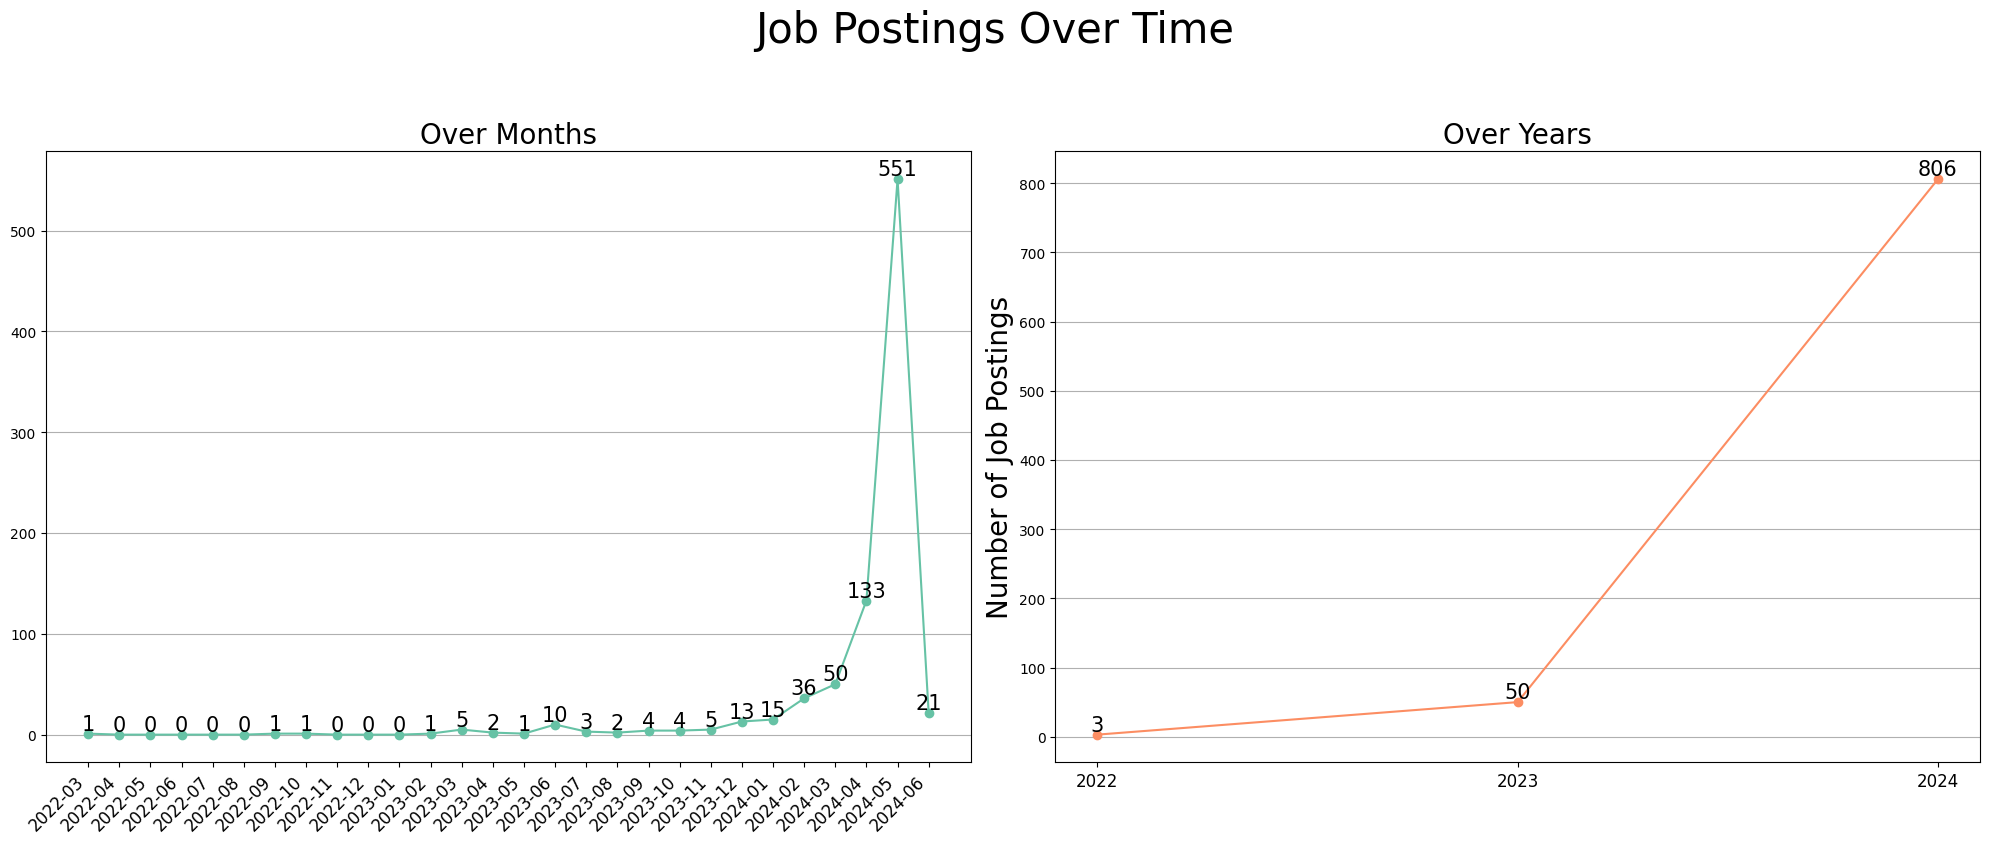

In [ ]:
Data["publishedAt"] = pd.to_datetime(Data["publishedAt"])

# Resample data
monthly_counts = Data.resample("M", on = "publishedAt").size()
yearly_counts = Data.resample("Y", on = "publishedAt").size()

# Reset index
monthly_counts = monthly_counts.reset_index(name = "Count")
yearly_counts = yearly_counts.reset_index(name = "Count")

# Format dates
monthly_counts["publishedAt"] = monthly_counts["publishedAt"].dt.strftime("%Y-%m")
yearly_counts["publishedAt"] = yearly_counts["publishedAt"].dt.strftime("%Y")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize = (20, 8))
plt.suptitle("Job Postings Over Time", fontsize = 30, y = 1.05)
plt.ylabel("Number of Job Postings", fontsize = 20)

# Monthly Job Postings
axes[0].plot(monthly_counts["publishedAt"], monthly_counts["Count"], linestyle = "-", marker = "o", color = MyColors[0])
axes[0].set_title("Over Months", fontsize = 20)
axes[0].set_xticks(monthly_counts["publishedAt"])
axes[0].set_xticklabels(monthly_counts["publishedAt"], rotation = 45, ha = "right", fontsize = 12)
axes[0].grid(axis = "y")
for i, count in enumerate(monthly_counts["Count"]):
    axes[0].text(i, count, str(count), ha = "center", va = "bottom", fontsize = 15)

# Yearly Job Postings
axes[1].plot(yearly_counts["publishedAt"], yearly_counts["Count"], linestyle = "-", marker = "o", color = MyColors[1])
axes[1].set_title("Over Years", fontsize = 20)
axes[1].set_xticks(yearly_counts["publishedAt"])
axes[1].set_xticklabels(yearly_counts["publishedAt"], rotation = 0, ha = "center", fontsize = 12)
axes[1].grid(axis = "y")
for i, count in enumerate(yearly_counts["Count"]):
    axes[1].text(i, count, str(count), ha = "center", va = "bottom", fontsize = 15)

plt.tight_layout()
plt.show()

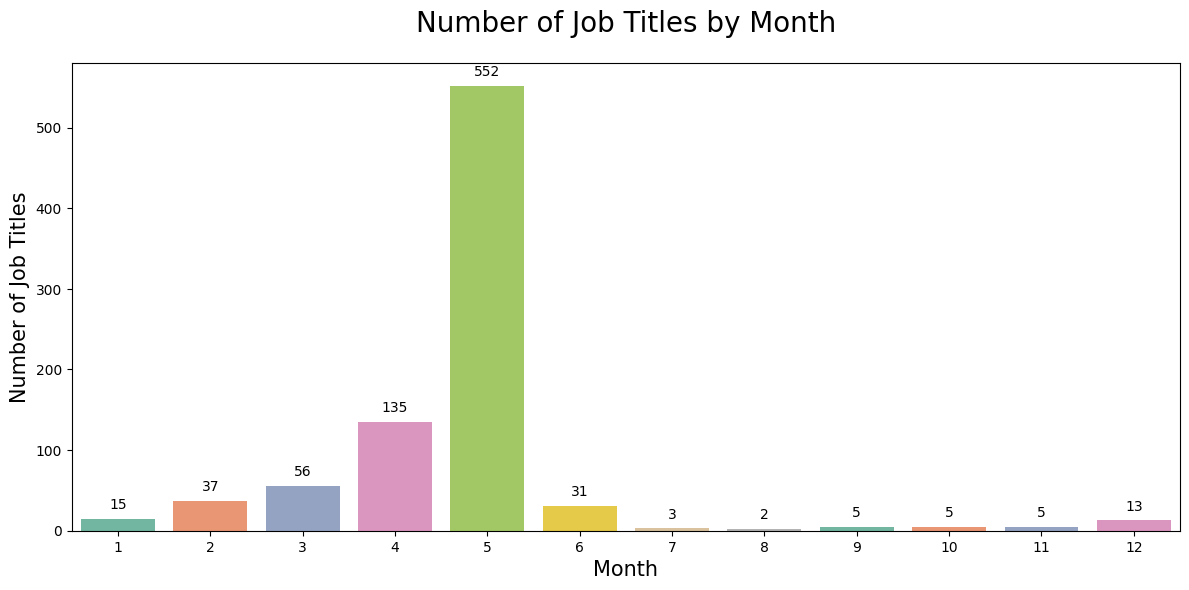

In [ ]:
# Group by month and count the number of titles
monthly_title_counts = Data.groupby("publishedMonth")["title"].count().reset_index(name = "TitleCount")

# Sort the results in descending order to find the month with the most titles
monthly_title_counts = monthly_title_counts.sort_values(by = "TitleCount", ascending = False)

# Identify the month with the highest count
highest_month = monthly_title_counts.iloc[0]

plt.figure(figsize = (12, 6))
bar = sns.barplot(data = monthly_title_counts, x = "publishedMonth", y = "TitleCount", palette = "Set2")

plt.title("Number of Job Titles by Month", fontsize = 20, y = 1.05)
plt.xlabel("Month", fontsize = 15)
plt.ylabel("Number of Job Titles", fontsize = 15)
plt.xticks(rotation = 0)

# Annotate the bars with their counts
for p in bar.patches:
    height = p.get_height() 
    bar.annotate(f"{int(height)}", 
                  (p.get_x() + p.get_width() / 2., height), 
                  ha = "center", va = "bottom", 
                  fontsize = 10, color = "black", 
                  xytext = (0, 5), 
                  textcoords = "offset points")

plt.tight_layout()  
plt.show()

> ## Conclusion:
> ### The demand for AI and ML professionals in the USA continues to grow at a strong pace, driven by the widespread adoption of AI technologies across industries such as healthcare, finance, e-commerce, and manufacturing. Job listings reflect a robust market, with roles like Machine Learning Engineer, AI/ML Engineer, and Artificial Intelligence Engineer being among the most sought-after. It is quite evident that with the passage of time, the growing need in this field is increasing significantly. On the other hand, demand in this area is very high in the first months of the year, especially in the month of May, which could be due to one of the following reasons:
> ### 1. Most companies set new budgets at the beginning of the fiscal year (usually January).
> ### 2. The start of the year is when many companies kick off new AI/ML initiatives.
> ### 3. In May, there’s a surge of fresh graduates entering the market, especially from master's and PhD programs in data science, AI, and CS.
> ### 4. Spring tends to be an active time for tech in general—conferences, product launches, and AI announcements (like Google I/O and Microsoft Build, often in May) can spark new demand.
> ### In summary, the AI and ML job market in the USA is thriving, offering high salaries, diverse roles, and strong growth potential for skilled professionals.

> ## 4.2. Experience Level Analysis

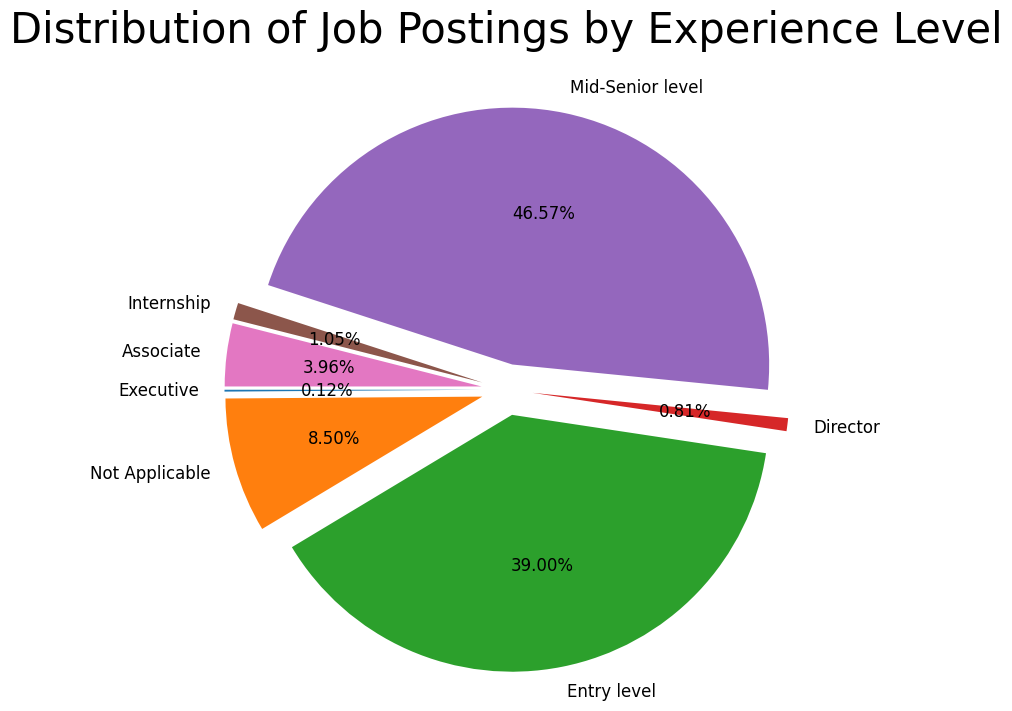

In [ ]:
experience_counts = Data["experienceLevel"].value_counts()
# Create a bar plot for the experience levels

# Shuffle the indices
shuffled_indices = np.random.permutation(len(experience_counts))

# Reorder the counts and labels based on the shuffled indices
shuffled_counts = experience_counts.iloc[shuffled_indices]
shuffled_labels = experience_counts.index[shuffled_indices]

plt.figure(figsize = (8, 8), dpi = 100)
plt.pie(shuffled_counts, labels = shuffled_labels, autopct = "%2.2f%%", startangle = 180,
         colors = MyColors, explode = [0.1] * len(shuffled_counts), textprops = {"fontsize": 12})

plt.title("Distribution of Job Postings by Experience Level", fontsize = 30, y = 1.05)
plt.axis("equal") 
plt.show()

> ## Conclusion:
> ### Entry-Level (0–2 years): Still relatively competitive, but demand is increasing, especially for roles like AI/ML analyst, junior data scientist, or research assistant. Companies often target new grads around May, which explains the spike in listings that require only basic experience or internship background.
> ### Mid-Senior (2–5 years): This is the sweet spot for most AI/ML roles. Employers often want a proven track record of real-world model development, deployment, and problem-solving. Mid-level professionals are attractive because they bring experience without the high cost of senior roles.

> ## 4.3. Job Title Analysis

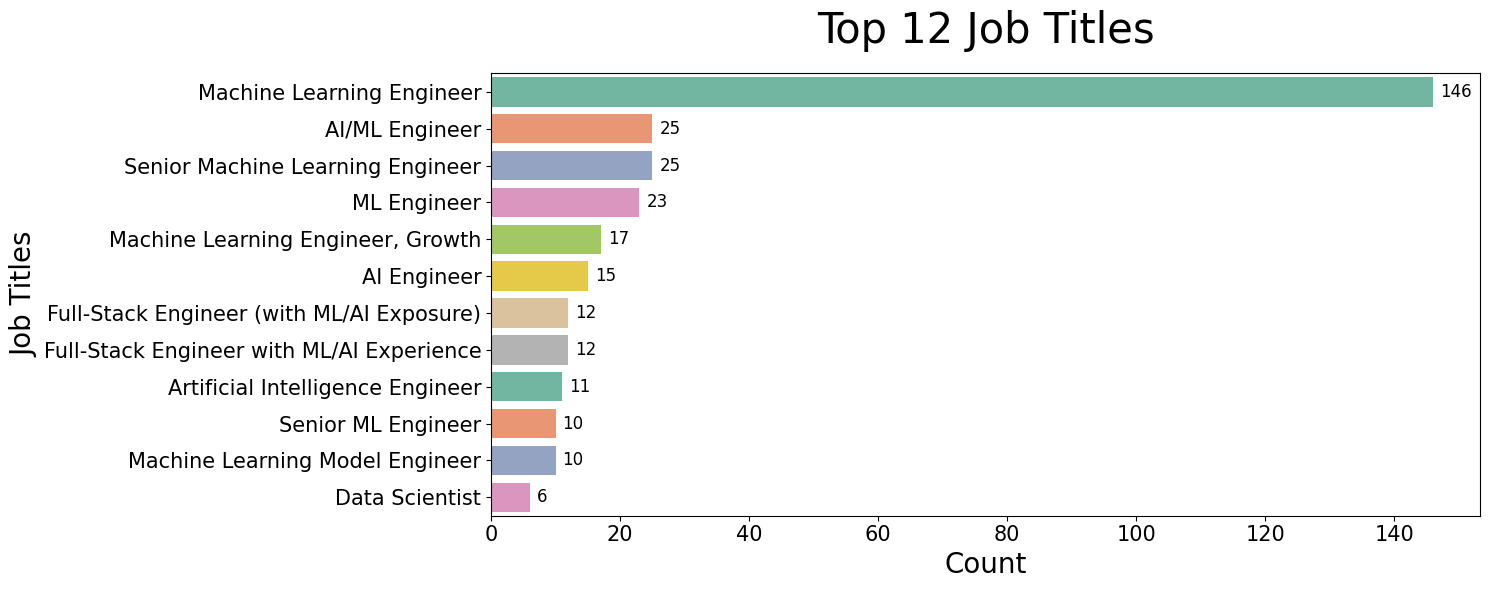

In [39]:
top12_jobTitle = Data["title"].value_counts().head(12)
    
plt.figure(figsize = (15, 6), dpi=100, facecolor = "white")

bars = sns.barplot(x = top12_jobTitle.values, y = top12_jobTitle.index, hue = top12_jobTitle.index, palette = "Set2", legend = False)

plt.title("Top 12 Job Titles", fontsize = 30, y = 1.05) 
plt.xlabel("Count", fontsize = 20)
plt.ylabel("Job Titles", fontsize = 20)
plt.xticks(rotation = 0, ha = "center", fontsize = 15)
plt.yticks(rotation = 0, ha = "right", fontsize = 15)

# Annotate the bars with their counts
for p in bars.patches:
    width = p.get_width()
    bars.annotate(f"{int(width)}", 
                  (width, p.get_y() + p.get_height() / 2.),
                  ha = "left", va = "center",
                  fontsize = 12, color = "black", 
                  xytext = (5, 0),
                  textcoords = "offset points")

plt.tight_layout()
plt.show()


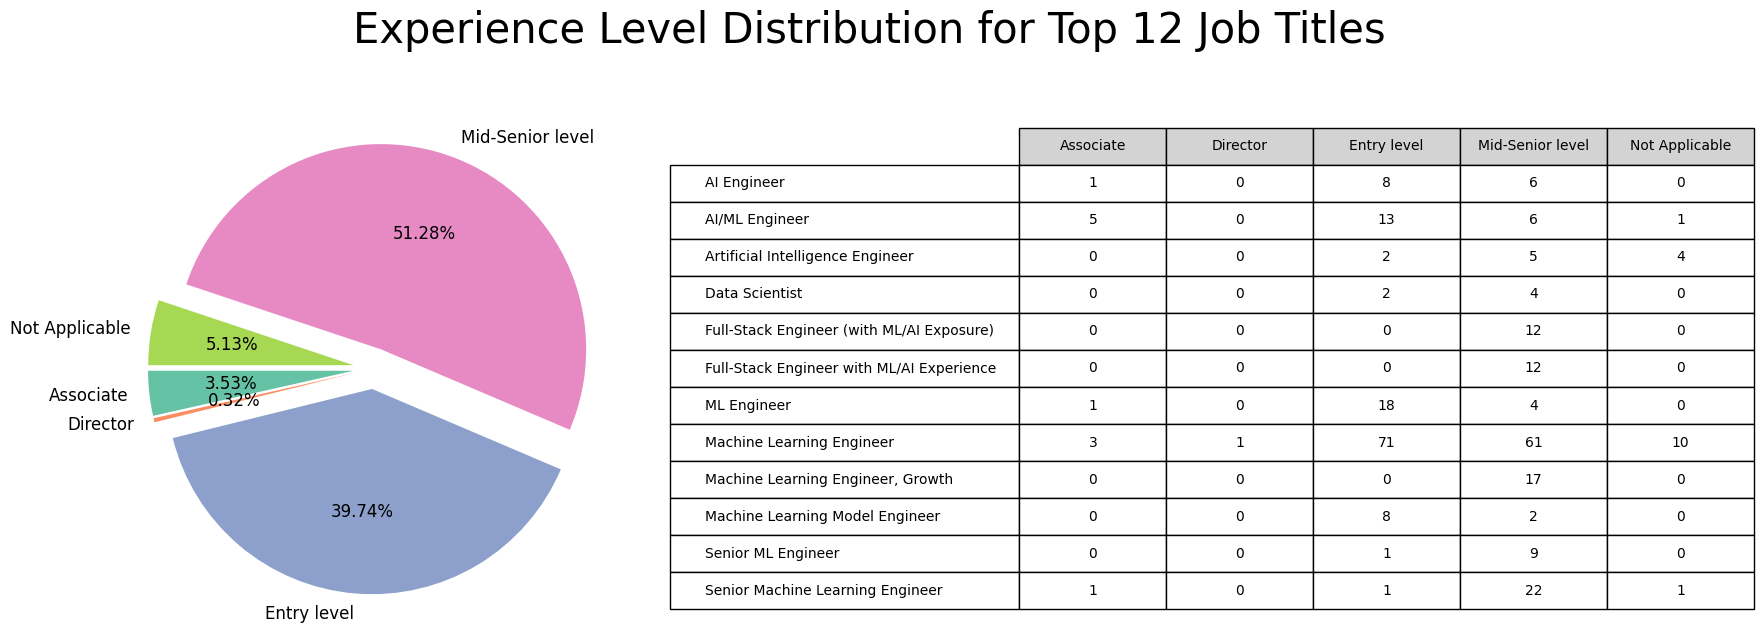

In [ ]:
# Filter the original DataFrame for these job titles
filtered_df = Data[Data["title"].isin(top12_jobTitle)]

# Select the relevant columns
experience_levels = filtered_df[["title", "experienceLevel"]]

# Count of each experience level for the top job titles
experience_level_counts = experience_levels.groupby(["title", "experienceLevel"]).size().reset_index(name = "count")

# Create a figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (18, 6))

# Set a common subtitle for both plots
fig.suptitle("Experience Level Distribution for Top 12 Job Titles", fontsize = 30, y = 1.05)

# Create a pie chart for the experience levels
experience_level_counts.groupby("experienceLevel")["count"].sum().plot.pie(
    ax=ax1,
    autopct="%2.2f%%",
    startangle=180,
    colors=MyColors,
    explode=[0.1] * len(experience_level_counts.groupby("experienceLevel")["count"].sum()),  # Explode all slices
    textprops={"fontsize": 12},
    legend=False
)

ax1.set_ylabel("")  # Hide the y-label

# Create a DataFrame for the table
table_data = experience_level_counts.pivot(index = "title", columns = "experienceLevel", values = "count").fillna(0)

table_data = table_data.astype(int)  # Convert counts to integers for better display

# Hide axes for the table
ax2.axis("tight")
ax2.axis("off")

# Create the table
table = ax2.table(cellText = table_data.values,
                  colLabels = table_data.columns,
                  rowLabels = table_data.index,
                  cellLoc = "center",
                  loc = "center")

table.auto_set_font_size(False)  # Disable automatic font size
table.set_fontsize(10)  # Set font size
table.scale(1, 2)  # Scale the table size

# Change header colors to grey
for (i, j), cell in table.get_celld().items():
    if i == 0:  # Header row
        cell.set_facecolor("#D3D3D3")  # Light grey background for headers

plt.tight_layout(rect = [0, 0, 1, 1])
plt.show()

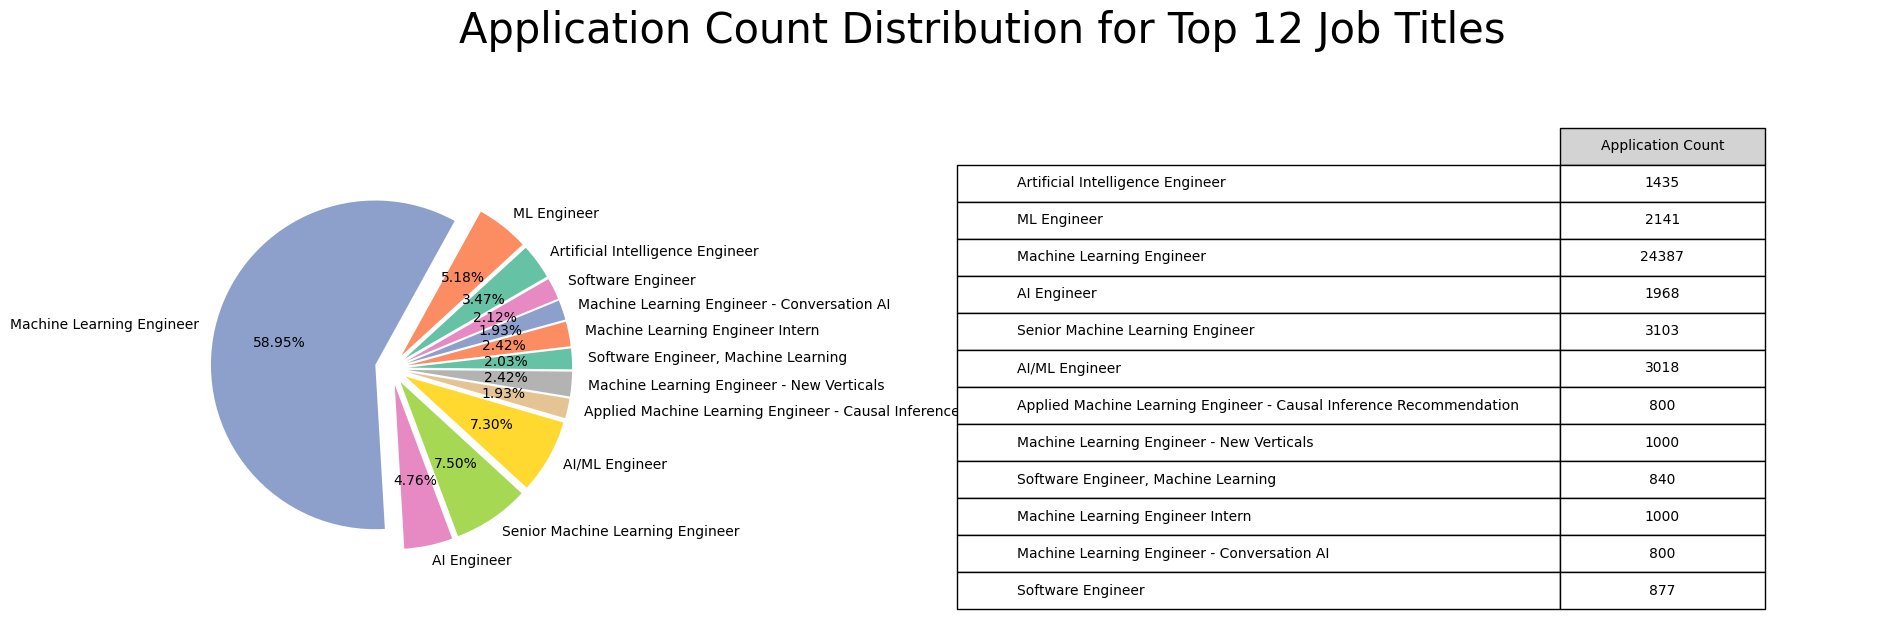

In [ ]:
# Ensure appCount is numeric
Data["appCount"] = pd.to_numeric(Data["appCount"], errors = "coerce")

# Filter the original DataFrame for these job titles
filtered_df = Data[Data["title"].isin(top12_jobTitle)]

# Calculate the total application counts for these job titles
appCounts = filtered_df.groupby("title")["appCount"].sum().reset_index()

# Shuffle the appCounts DataFrame
shuffled_appCounts = appCounts.sample(frac = 1).reset_index(drop = True)  # Shuffle the DataFrame

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (18, 6))

# Set a common subtitle for both plots
fig.suptitle("Application Count Distribution for Top 12 Job Titles", fontsize = 30, y = 1.05)

# Create a pie chart for the application counts using the shuffled data
ax1.pie(shuffled_appCounts["appCount"], labels = shuffled_appCounts["title"], autopct = "%2.2f%%", startangle = 30,
         colors = MyColors, explode = [0.1] * len(shuffled_appCounts), textprops = {"fontsize": 10})

ax1.set_ylabel("")  # Hide the y-label

# Create a DataFrame for the table
table_data = shuffled_appCounts.set_index("title")  # Set title as index for the table

# Hide axes for the table
ax2.axis("tight")
ax2.axis("off")

# Create the table
table = ax2.table(cellText = table_data.values,
                  colLabels = ["Application Count"],
                  rowLabels = table_data.index,
                  cellLoc = "center",
                  loc = "center")

table.auto_set_font_size(False)  # Disable automatic font size
table.set_fontsize(10)  
table.scale(0.5, 2)

# Change header colors to grey
for (i, j), cell in table.get_celld().items():
    if i == 0:  # Header row
        cell.set_facecolor("#D3D3D3")  # Light grey background for headers

plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to make space for the suptitle
plt.show()

> ## Conclusion:
> ### The most sought-after job title is Machine Learning Engineering with experience with Mid-Senior Level. This field requires many skills such as mastery of various Python libraries, artificial intelligence tools, machine learning and deep learning techniques, methods and algorithms, mastery of simulation,measurement and visualization and libraries, and a variety of other skills, abilities and tools.

> ## 4.4. Location Analysis

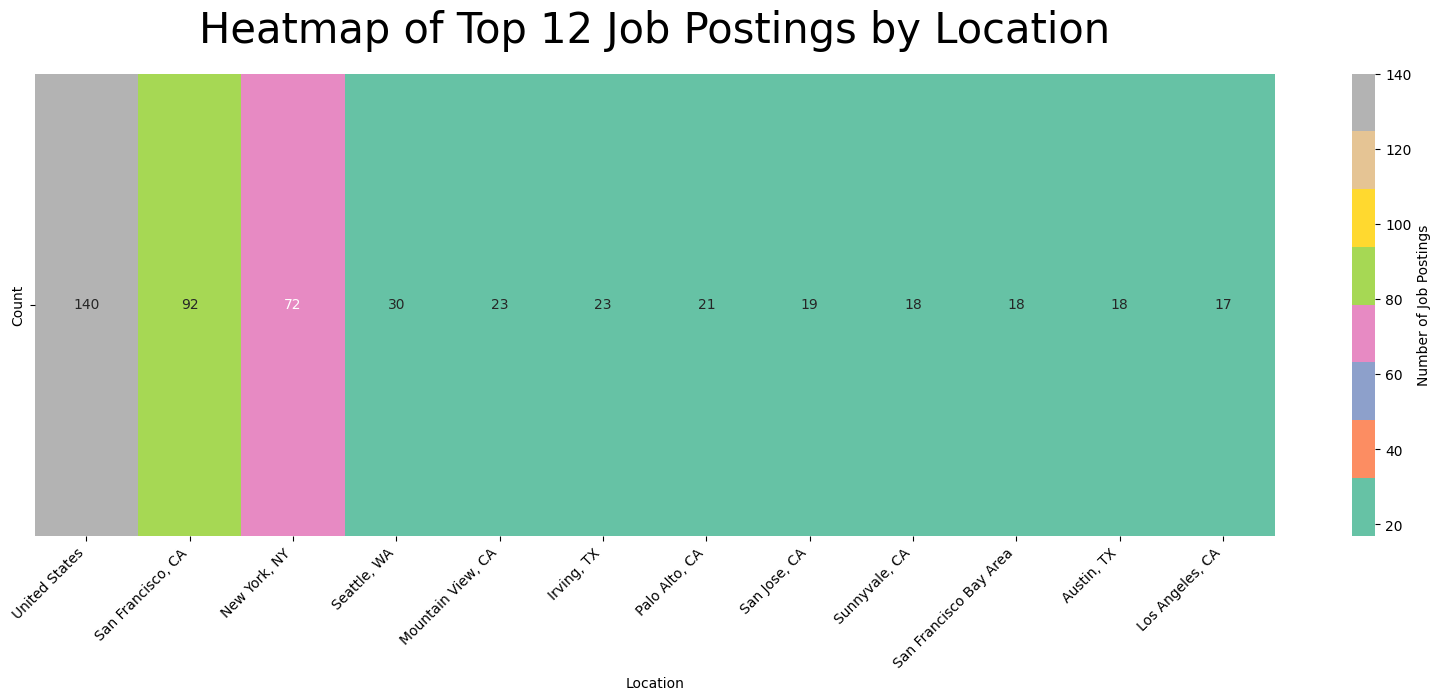

In [ ]:
location_counts = Data["location"].value_counts().head(12)
# Create a bar plot for the top 12 locations

# Convert the location counts to a DataFrame
location_counts_df = location_counts.reset_index()
location_counts_df.columns = ["Location", "Count"]

# Create a heatmap
plt.figure(figsize = (20, 6))

# Reshape the DataFrame to have a single row for the heatmap
heatmap_data = location_counts_df.set_index("Location").T  # Transpose to have locations as columns
sns.heatmap(heatmap_data, annot = True, fmt = "d", cmap = "Set2", cbar_kws = {"label": "Number of Job Postings"})
plt.title("Heatmap of Top 12 Job Postings by Location", fontsize = 30, y = 1.05)
plt.xlabel("Location")
plt.xticks(rotation = 45, ha = "right")
plt.show()

> ## 4.5. Contract Type Analysis

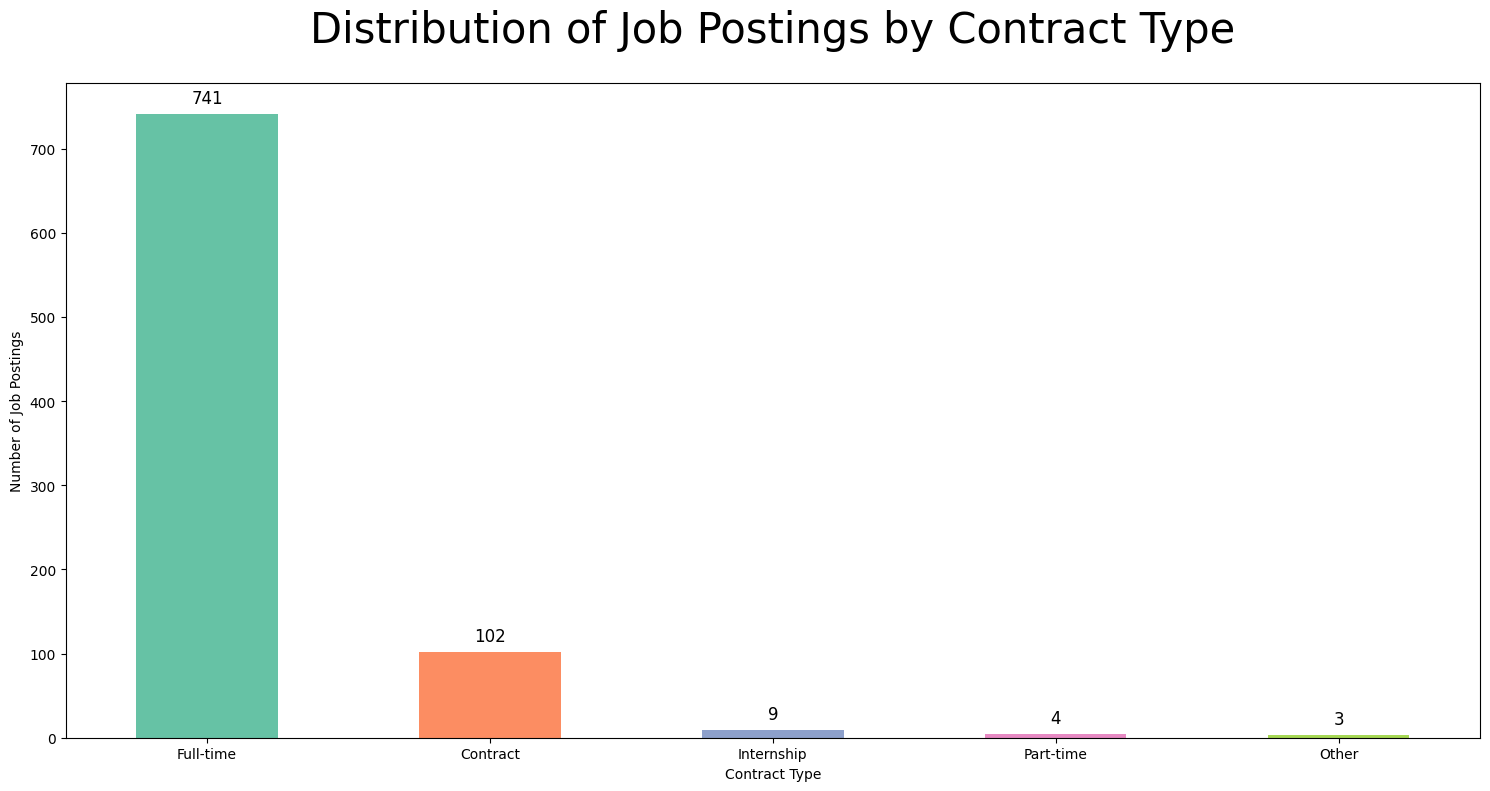

In [ ]:
# Count the occurrences of each contract type
contract_counts = Data["contractType"].value_counts()

plt.figure(figsize = (15, 8))
co = contract_counts.plot(kind = "bar", color = MyColors)
plt.title("Distribution of Job Postings by Contract Type", fontsize = 30, y = 1.05)
plt.ylabel("Number of Job Postings")
plt.xticks(rotation = 0)
plt.xlabel("Contract Type")

# Annotate the bars with their counts
for p in co.patches:
    height = p.get_height() 
    co.annotate(f"{int(height)}", 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha = "center", va = "bottom", 
                 fontsize = 12, color = "black", 
                 xytext = (0, 5),
                 textcoords = "offset points")

plt.tight_layout()
plt.show()

> ## 4.6. Company Analysis

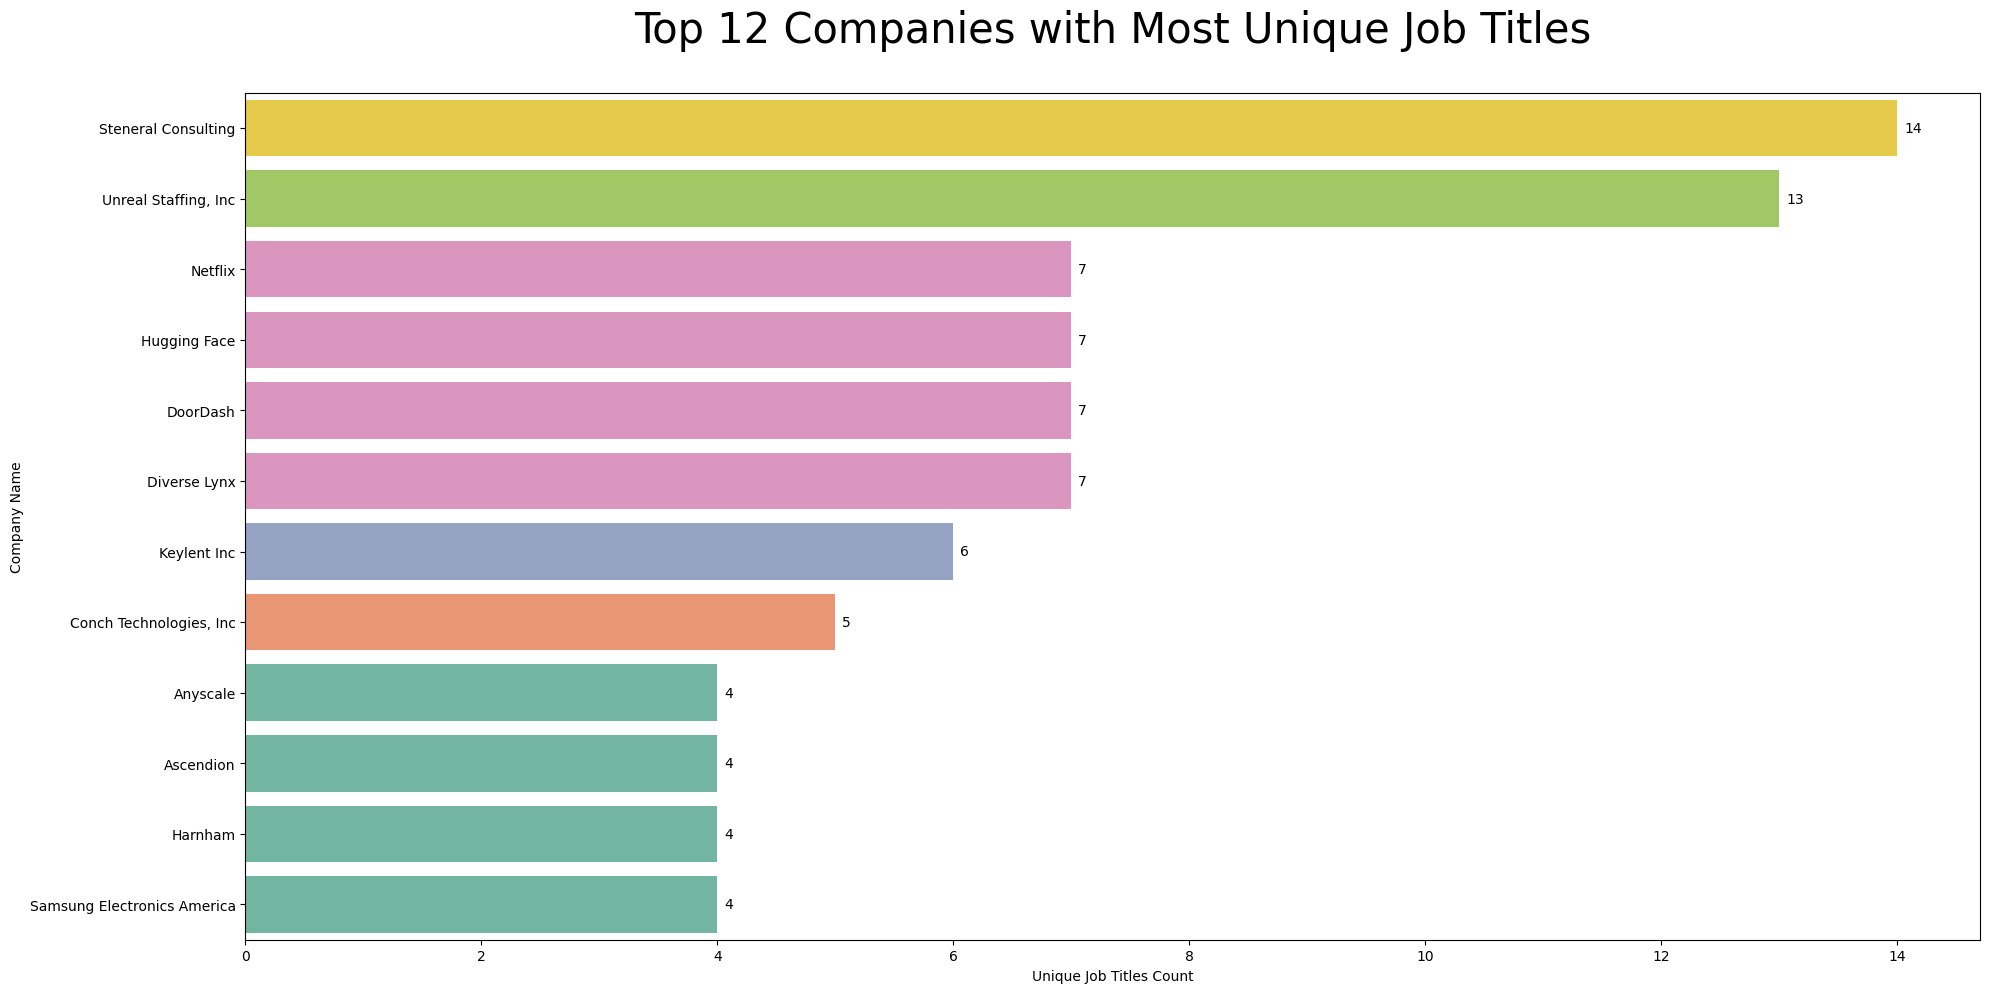

In [408]:
# Group by "companyName" and count unique job titles
titles_by_company = Data.groupby("companyName")["title"].nunique().reset_index()

# Rename the columns for clarity
titles_by_company.columns = ["companyName", "JobTitlesCount"]

# Sort the results in descending order to find the companies with the most unique job titles
titles_by_company = titles_by_company.sort_values(by = "JobTitlesCount", ascending = False)

plt.figure(figsize = (20, 10))
bars = sns.barplot(data = titles_by_company.head(12), x = "JobTitlesCount", y = "companyName",hue = "JobTitlesCount",  palette = "Set2", legend = False)
plt.title("Top 12 Companies with Most Unique Job Titles", fontsize = 30, y = 1.05)
plt.xlabel("Unique Job Titles Count")
plt.ylabel("Company Name")

for p in bars.patches:
    width = p.get_width() 
    bars.annotate(f"{int(width)}", 
                  (width, p.get_y() + p.get_height() / 2.), 
                  ha = "left", va = "center",  
                  fontsize = 10, color = "black", 
                  xytext = (5, 0),  
                  textcoords = "offset points")
    

plt.tight_layout()
plt.show()

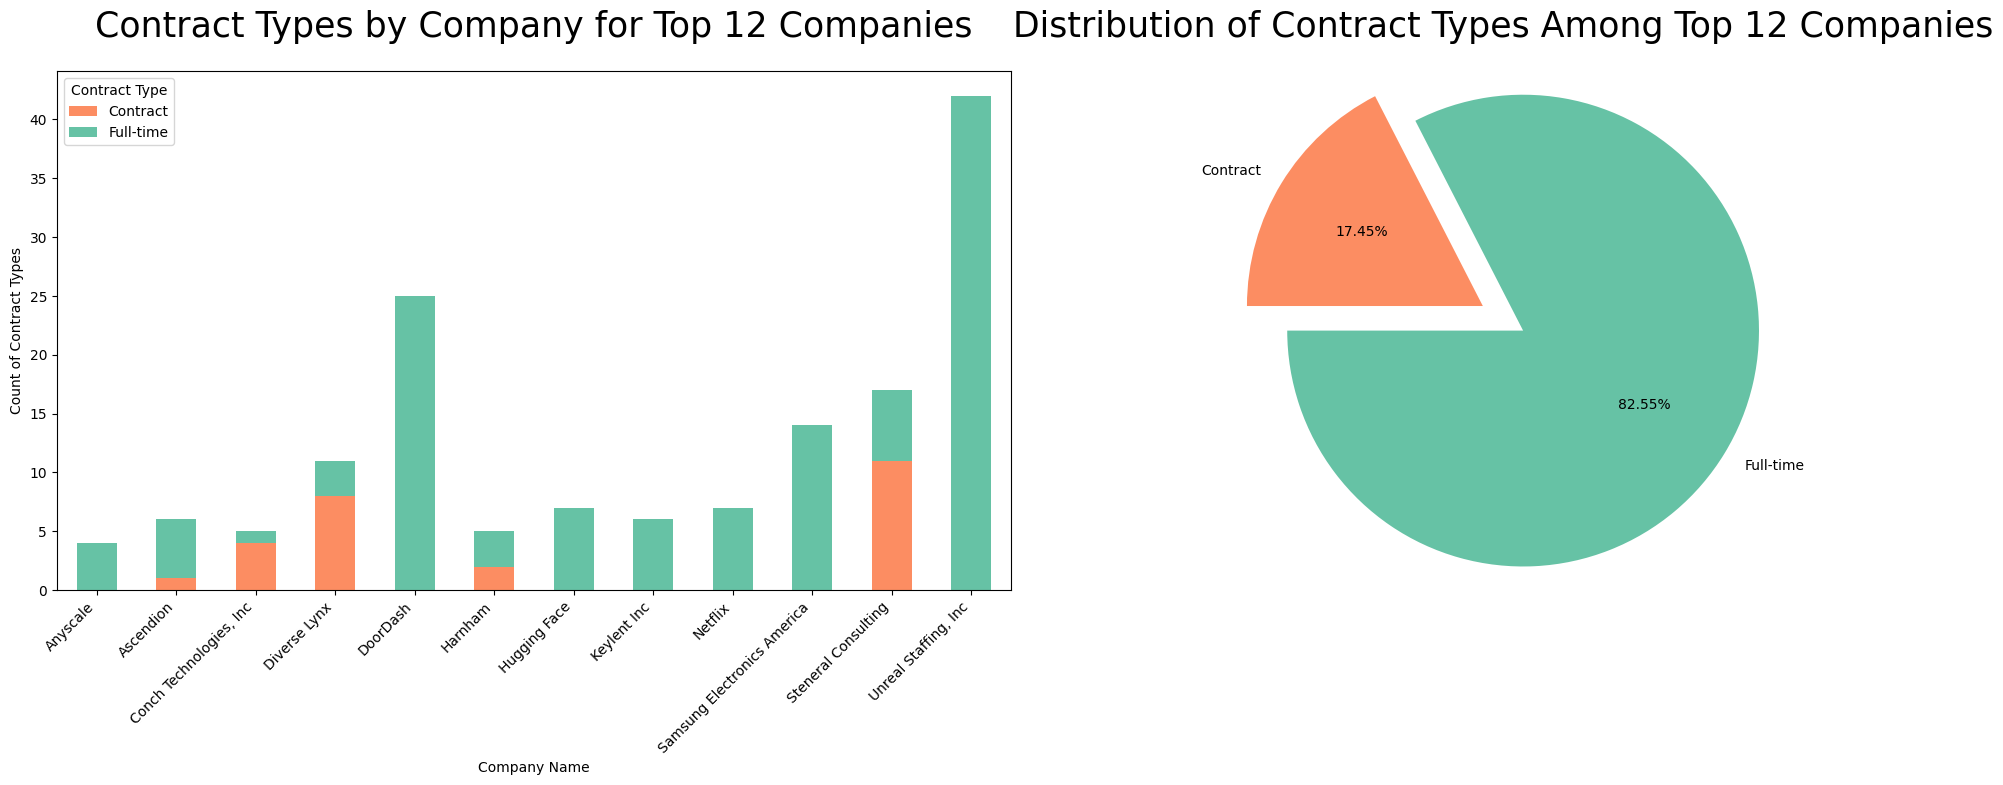

In [ ]:
top_12_companies = titles_by_company.head(12)["companyName"]

# Filter the original DataFrame for these companies
filtered_data = Data[Data["companyName"].isin(top_12_companies)]

# Group by companyName and contractType, and count occurrences
contract_types_by_company = filtered_data.groupby(["companyName", "contractType"]).size().reset_index(name = "Count")

# Sort the results for better readability
contract_types_by_company = contract_types_by_company.sort_values(by = ["companyName", "Count"], ascending = [True, False])

# Create a pivot table for better visualization
pivot_table = contract_types_by_company.pivot(index = "companyName", columns = "contractType", values = "Count").fillna(0)

# Get unique contract types and define a color palette
unique_contract_types = contract_types_by_company["contractType"].unique()
colors = sns.color_palette("Set2", n_colors = len(unique_contract_types))

# Create a color mapping for consistent colors
color_mapping = {contract_type: colors[i] for i, contract_type in enumerate(unique_contract_types)}

fig, axes = plt.subplots(1, 2, figsize = (20, 8))

# Bar Chart
pivot_table.plot(kind = "bar", stacked = True, color = [color_mapping.get(col, "#333333") for col in pivot_table.columns], ax = axes[0])
axes[0].set_title("Contract Types by Company for Top 12 Companies", fontsize=25, y=1.05)
axes[0].set_xlabel("Company Name")
axes[0].set_ylabel("Count of Contract Types")
axes[0].set_xticklabels(pivot_table.index, rotation = 45, ha = "right")  # Rotate x-axis labels for better readability
axes[0].legend(title = "Contract Type")

# Pie Chart
top_companies_data = Data[Data["companyName"].isin(top_12_companies)]
contract_counts = top_companies_data["contractType"].value_counts()

# Use the same color mapping for the pie chart
pie_colors = [color_mapping.get(x, "#333333") for x in contract_counts.index]
axes[1].pie(contract_counts, labels = contract_counts.index, autopct = "%2.2f%%", startangle = 180, colors = pie_colors, explode = [0.1]*len(contract_counts))
axes[1].set_title("Distribution of Contract Types Among Top 12 Companies", fontsize = 25, y = 1.05)
axes[1].axis("equal")

plt.tight_layout()
plt.show()

> ## 4.7. Description Analysis

> ## 4.7.1. Salary

In [346]:
# Filter rows containing the word "Salary" or "salary"
salary_rows = Data[Data["description"].str.contains(r"\bsalary\b", case=False, na=False)]

# Display the filtered rows
salary_rows[["title", "description"]]

,title,description
0,AI/ML Engineer,THE OPPORTUNITY\n\nWesper is looking for a sma...
1,Software Engineer - AI/ML Systems,We're on a mission to democratize AI by buildi...
3,Machine Learning Engineer (L4) - Infrastructur...,At Netflix our goal is to entertain the world....
6,Junior Machine Learning Engineer,This is a remote position.\n\nDISCLAIMER: This...
9,ML/AI Engineer - Optimization,Cognitive Space uses the power of AI to help o...
...,...,...
850,"Machine Learning Engineer, Responsible AI",Grammarly is excited to offer a remote-first h...
851,Software Engineer (Ray Data),"About Anyscale:\n\n\n\nAt Anyscale, we're on a..."
852,"(USA) Staff, Data Scientist - ML Engineer",Position Summary...\n\nWhat you'll do...\n\nTh...
859,Machine Learning Engineer,"Hi, We're Centerfield.\n\nSupercharged custome..."


> ### Given that out of 862 rows, only 346 rows include salaries, and of these 346 rows, many do not mention salary ranges, making the rest of the data disproportionate.

> ## 4.7.2. Most Used Words

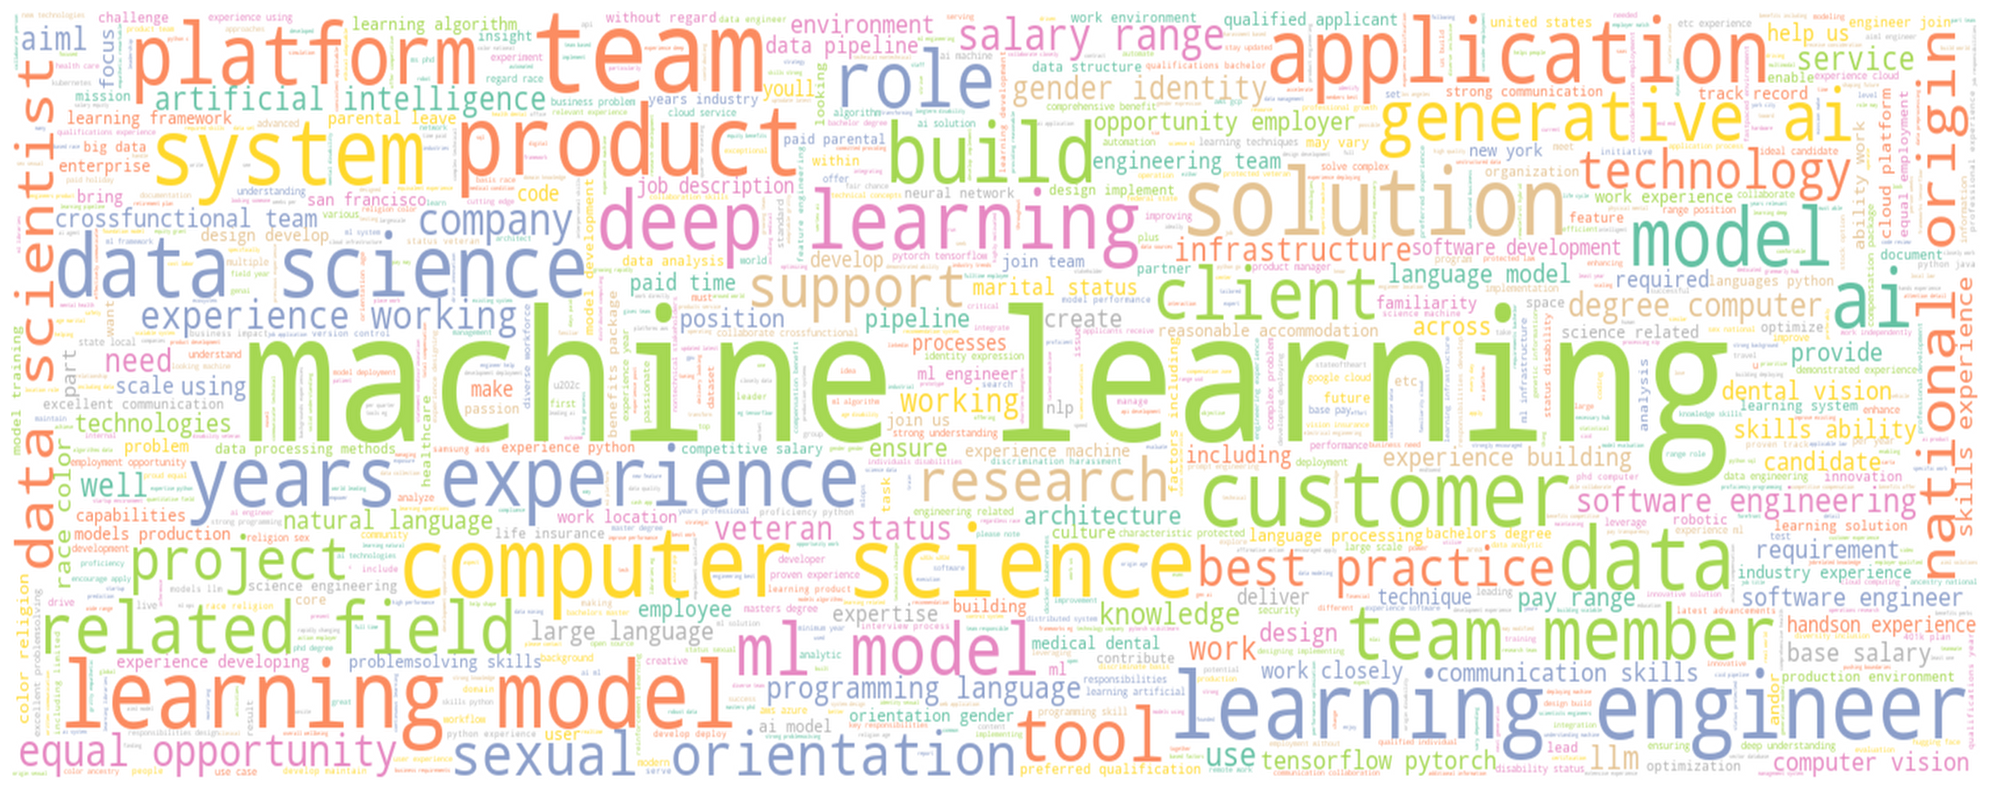

In [ ]:
text = " ".join(Data["description.RAKE"].dropna().astype(str))

# Generate the word cloud
wordcloud = WordCloud(
    width = 1500,
    height = 500,
    background_color = "white",
    colormap = "Set2",
    max_words = 10000, 
    contour_width = 10000 
).generate(text)

# Display the word cloud
plt.figure(figsize = (20, 8))  
plt.imshow(wordcloud, interpolation = "bessel", aspect = "auto", cmap = "Set2")
plt.axis("off")
plt.tight_layout()
plt.show()

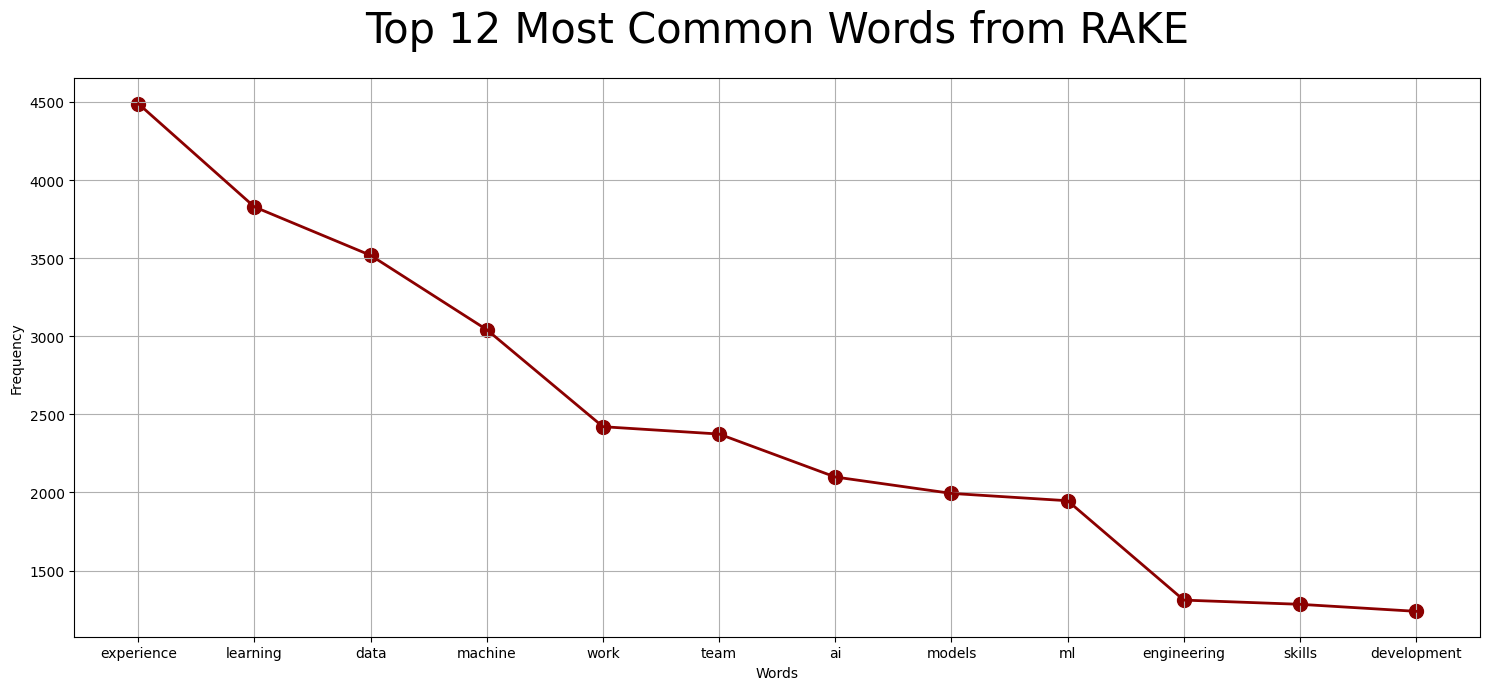

In [ ]:
# Clean the text
# Remove punctuation and make everything lowercase
cleaned_text = re.sub(r"[^\w\s]", "", text.lower())

# Count word frequencies
word_counts = Counter(cleaned_text.split())

# Get the 12 most common words
most_common_words = word_counts.most_common(12)

# Create lists for the words and their frequencies
words, frequencies = zip(*most_common_words)

# Create a scatter plot
plt.figure(figsize=(15, 7))
plt.scatter(words, frequencies, color = "darkred", s = 100)  
plt.plot(words, frequencies, color = "darkred", linestyle = "-", linewidth = 2)  
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 12 Most Common Words from RAKE", fontsize = 30, y = 1.05)
plt.grid(True)

plt.tight_layout()  
plt.show()

> ### 4.7.3.Skills

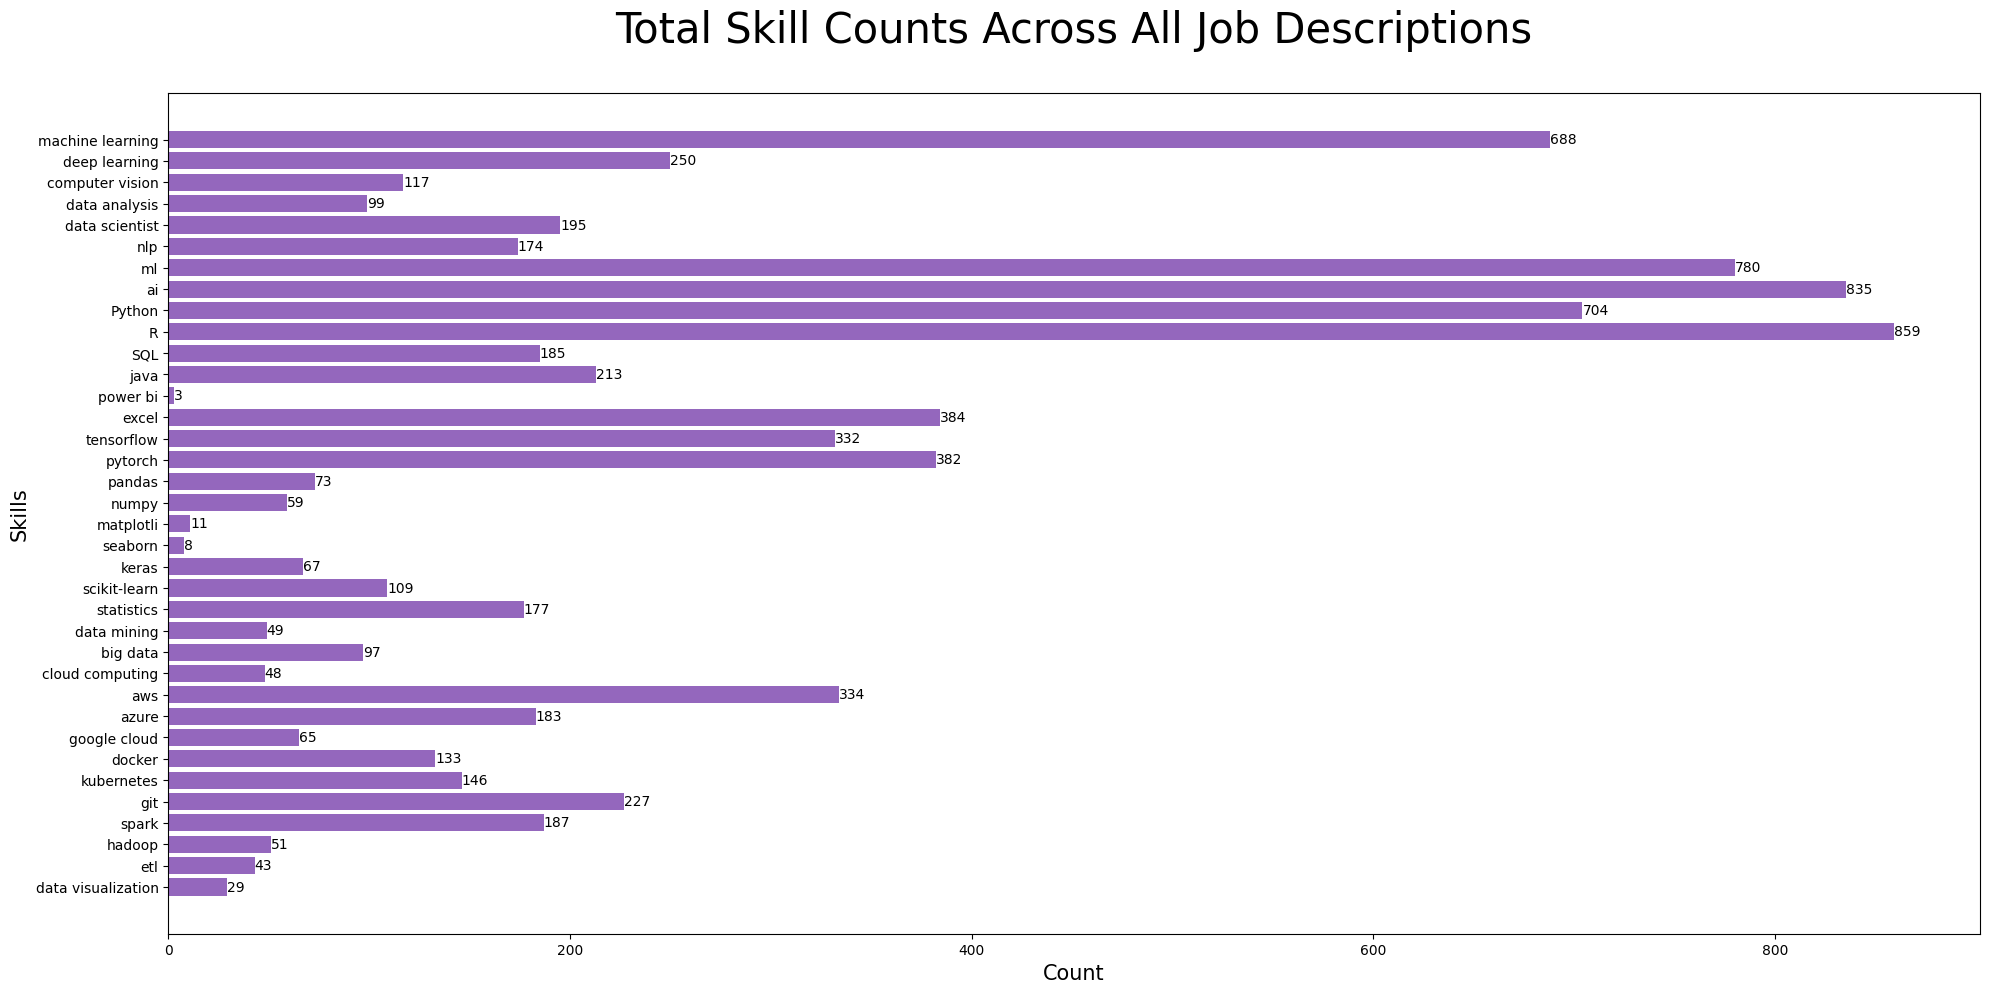

In [ ]:
# List of skills to count
skills_list = ["machine learning", "deep learning", "computer vision", "data analysis", 
               "data scientist", "nlp", "ml", "ai", "Python", "R", "SQL", "java",
               "power bi", "excel", "tensorflow", "pytorch", "pandas", "numpy","matplotli", "seaborn", "keras",
               "scikit-learn", "statistics", "data mining", "big data", "cloud computing", 
               "aws", "azure", "google cloud", "docker", "kubernetes", "git",
               "spark", "hadoop", "etl", "data visualization", 
               ]

def extract_skills(description):
    skills = []
    for skill in skills_list:
        if re.search(skill, description, re.IGNORECASE):
            skills.append(skill)
    return skills

# Apply the function to extract skills
Data["skills"] = Data["description"].apply(extract_skills)

# Count total occurrences of each skill across all job descriptions
total_skill_counts = {skill: 0 for skill in skills_list}

for skills in Data["skills"]:
    for skill in skills:
        total_skill_counts[skill] += 1

# Convert the counts to a DataFrame for easier visualization
total_skill_counts_df = pd.DataFrame(list(total_skill_counts.items()), columns = ["Skill", "Count"])

# Horizontal Bar Chart Visualization
plt.figure(figsize = (20, 10))  # Adjusted figure size for better readability
plt.barh(total_skill_counts_df["Skill"], total_skill_counts_df["Count"], color = MyColors[4])
plt.gca().invert_yaxis()  # Invert y-axis to have the highest count on top
plt.title("Total Skill Counts Across All Job Descriptions", fontsize = 30, y = 1.05)
plt.xlabel("Count", fontsize = 15)
plt.ylabel("Skills", fontsize = 15)

for index, value in enumerate(total_skill_counts_df["Count"]):
    plt.text(value, index, str(value), va = "center", fontsize = 10, color = "black")

plt.tight_layout()
plt.show()


> # Conclusion

> ## Machine learning (ML) is a branch of artificial intelligence that enables systems to learn from data, identify patterns, and make decisions with minimal human intervention. It is the engine behind many transformative technologies, including recommendation systems, fraud detection, medical diagnosis tools, autonomous vehicles, and natural language processing.

> ## As computing power grows and data becomes more abundant, ML will be embedded into nearly every digital interaction, reshaping jobs, industries, and society. The future of ML is incredibly promising and central to the digital transformation of industries